<img src="https://images.unsplash.com/photo-1551836022-d5d88e9218df?w=1200&auto=format&fit=crop&q=80" width="100%" style="border-radius: 8px;">

# 📊 Telecom Customer Churn Prediction & MLOps Pipeline
> **Author:** Matías Díaz  
> **Area:** Customer Analytics & Predictive Modeling  
> **Tech Stack:** Python, Pandas, Scikit-Learn, MLflow, SHAP  

---

### 📋 Business Problem Description
Customer churn is one of the most critical metrics in the telecommunications sector. Retaining an existing customer costs significantly less than acquiring a new one.

**Project Objectives:**
1. **Identify key behavioral patterns** associated with service cancellation.
2. **Build an optimized predictive model** to maximize the early detection of at-risk customers (target metric: *ROC-AUC* / *Recall*).
3. **Explain the predictions** using interpretability techniques (SHAP) to suggest automated retention strategies.

---

# 1. Data Loading and Initial Radiography (EDA)

---



In [12]:
import numpy as np
import pandas as pd

# We read the dataset directly from the source
data = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")

# Show the first 5 rows
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# Dataset size
data.shape

(7043, 21)

In [14]:
# 1. General information on columns and data types
print("--- Dataset Information ---")
data.info()

# 2. Distribution of the target variable
print("\n--- Churn Percentage ---")
print(data['Churn'].value_counts(normalize=True) * 100)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

In [15]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 2. Data Cleaning and Base Preprocessing

In [16]:
# 1. Drop identifier that adds no value to the model, has no predictive power, and can cause overfitting.
df_clean = data.drop(columns=['customerID']).copy()

# 2. Fix TotalCharges (convert text with spaces to numeric values). We noticed it is an object type and we need it as numeric to perform operations.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].str.strip(), errors='coerce')

# 3. Impute generated nulls with the median
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# 4. Convert Churn to binary (1 and 0)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Confirmation
print(f"Total null values after cleaning: {df_clean.isnull().sum().sum()}")
df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head()

Total null values after cleaning: 0


,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,1
3,45,42.30,1840.75,0
4,2,70.70,151.65,1


# 3. Visual Exploratory Analysis (Business Insights)

/tmp/ipykernel_2553/2044136747.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Contract', y='Churn', palette='Set2', errorbar=None)
/tmp/ipykernel_2553/2044136747.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')


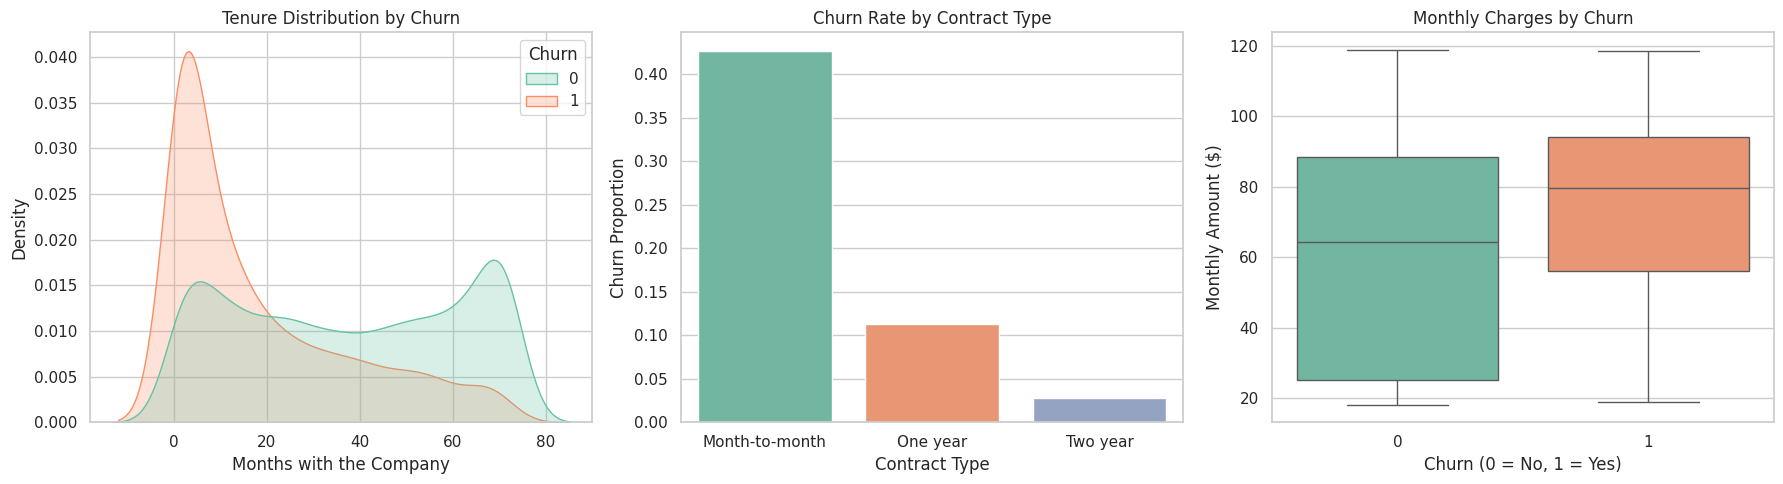

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# 1. Tenure vs Churn Plot
plt.subplot(1, 3, 1)
sns.kdeplot(data=df_clean, x='tenure', hue='Churn', common_norm=False, palette='Set2', fill=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Months with the Company')
plt.ylabel('Density')

# 2. Contract Type vs Churn Plot
plt.subplot(1, 3, 2)
sns.barplot(data=df_clean, x='Contract', y='Churn', palette='Set2', errorbar=None)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Proportion')

# 3. Monthly Charges vs Churn Plot
plt.subplot(1, 3, 3)
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Amount ($)')

plt.tight_layout()
plt.show()

# 4. Variable Encoding and Train/Test Split

In [32]:
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target variable (y)
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# 2. Categorical variable encoding (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split into Training and Testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Generated features (columns): {X_encoded.shape[1]}")
print(f"Records in Train: {X_train.shape[0]} | Records in Test: {X_test.shape[0]}")

Generated features (columns): 30
Records in Train: 5634 | Records in Test: 1409


# 5. Predictive Modeling and Experiment Tracking (MLflow)

In [33]:

# Install MLflow
!pip install -q mlflow

import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Setting MLflow
mlflow.set_experiment("Telecom_Churn_Prediction")
print("MLflow OK.")


MLflow OK.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/08/17 17:40:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Logistic_Regression_Balanced ===
ROC-AUC Score: 0.8420

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



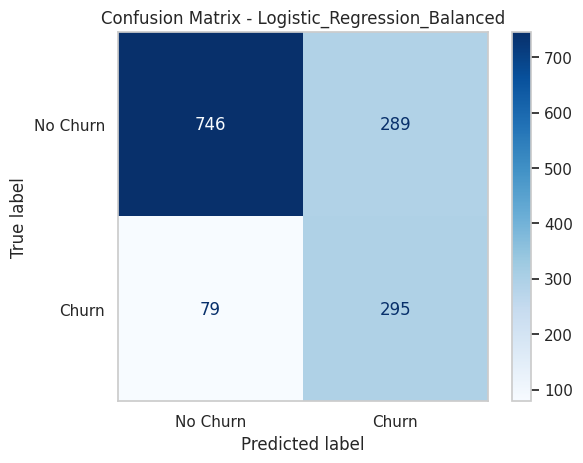

2026/08/17 17:40:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Random_Forest_Balanced ===
ROC-AUC Score: 0.8209

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



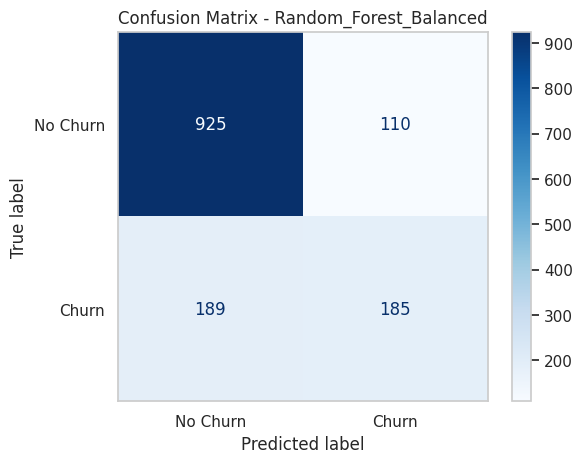

In [34]:
# Function to train, evaluate, and log a model in MLflow
def train_and_log_model(model, model_name, X_tr, y_tr, X_te, y_te):
    with mlflow.start_run(run_name=model_name):
        # 1. Train model
        model.fit(X_tr, y_tr)

        # 2. Predictions
        y_pred = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        # 3. Metrics
        roc_auc = roc_auc_score(y_te, y_proba)

        # 4. Log parameters and metrics in MLflow
        mlflow.log_param("model_type", model_name)
        if hasattr(model, 'class_weight'):
            mlflow.log_param("class_weight", str(model.class_weight))

        mlflow.log_metric("roc_auc", roc_auc)

        # Save the model in MLflow
        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"=== {model_name} ===")
        print(f"ROC-AUC Score: {roc_auc:.4f}\n")
        print("Classification Report:")
        print(classification_report(y_te, y_pred, target_names=['No Churn', 'Churn']))

        # Visualize Confusion Matrix
        cm = confusion_matrix(y_te, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {model_name}")
        plt.grid(False)
        plt.show()

# Experiment 1: Logistic Regression (Balanced baseline)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
train_and_log_model(lr_model, "Logistic_Regression_Balanced", X_train, y_train, X_test, y_test)

# Experiment 2: Random Forest (Ensemble Model)
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
train_and_log_model(rf_model, "Random_Forest_Balanced", X_train, y_train, X_test, y_test)

"Although Random Forest shows a superior accuracy (79% vs 74%), in a churn problem, accuracy is a misleading metric. Logistic Regression outperformed Random Forest with an ROC-AUC of 0.8420 and a recall rate of 79%, successfully capturing 295 of the 374 customers at risk of cancellation."

# 6. Business Model Explainability and Impact (SHAP Values)
>In this section we use **SHAP (SHapley Additive exPlanations)** to open the "black box" of the selected model (**Logistic Regression**) and identify which behavioral and service variables have the greatest quantitative weight in the probability that a customer will cancel their subscription.

In [ ]:
# 1. Install SHAP
!pip install -q shap

import shap
import matplotlib.pyplot as plt

# 2. Convert the data to float to avoid boolean type errors in NumPy/SHAP
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

# 3. Configure the explainer for Logistic Regression
explainer = shap.LinearExplainer(lr_model, X_train_shap)
shap_values = explainer(X_test_shap)

# 4. Global impact chart of variables (Summary Plot)
shap.summary_plot(shap_values, X_test_shap)

# 7. Business Conclusions and Recommendations

### 📌 Technical and Strategic Findings
* **Business Metrics Prioritization:** **Logistic Regression with class weight balancing** (`ROC-AUC = 0.8420`) was selected over Random Forest. Although Random Forest showed a higher overall *Accuracy* (79%), Logistic Regression maximized **Recall (79%)**, successfully capturing **295 out of 374 actual at-risk customers**.
* **Identified Churn Profile:** The probability of Churn increases drastically in customers with **less than 12 months of tenure**, **month-to-month** contracts, high monthly charges, and **Fiber Optic** service.

---

### 🚀 Actionable Recommendations and Action Plan
1. **Early Retention Program (Onboarding):** Implement loyalty campaigns and progressive discounts during the customer's first 12 months to overcome the critical churn window.
2. **Contract Migration Incentives:** Design exclusive promotions to convert *Month-to-month* customers to **1 or 2-year** contracts, the strongest retention factor detected by the model.
3. **Service Bundling:** Offer bonuses for *Online Security* and *Tech Support*, as the SHAP analysis demonstrates that adopting these services significantly reduces the probability of cancellation.
4. **Fiber Optic Product Review:** Conduct a satisfaction audit among Fiber Optic users to correct issues related to price perception or service stability.